# Chapter 27 — Complex Numbers (Intuition)

> **Prerequisites:** ch026 (Real Numbers), ch025 (Irrational Numbers)
> 
> **You will learn:**
> - Why complex numbers were introduced and what operation they close ℝ under
> - The geometric interpretation: complex numbers as 2D vectors
> - Euler's formula: $e^{i\theta} = \cos\theta + i\sin\theta$
> - Practical uses in signal processing and rotation
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Complex numbers were invented to solve $x^2 + 1 = 0$, which has no real solution. Define $i = \sqrt{-1}$ and every polynomial equation suddenly has solutions — this is the Fundamental Theorem of Algebra: every degree-$n$ polynomial has exactly $n$ complex roots (counting multiplicity).

A complex number is $z = a + bi$ where $a, b \in \mathbb{R}$. $a$ is the **real part**, $b$ the **imaginary part**.

**Common misconception:** "Complex numbers are made-up or less real than real numbers." Every number system was 'invented' to solve a specific problem. Complex numbers are just as rigorously defined as integers or irrationals — and they are indispensable in physics, signal processing, and control theory.

## 2. Intuition & Mental Models

**Complex numbers as 2D vectors:** $z = a + bi$ corresponds to the point $(a, b)$ in the plane. Adding complex numbers is vector addition. Multiplying by $i$ is rotation by 90°.

**Polar form:** Every complex number has a magnitude $r = |z| = \sqrt{a^2 + b^2}$ and angle $\theta = \arg(z) = \arctan(b/a)$. Multiplication becomes: multiply magnitudes, add angles. This makes complex numbers the natural language for rotations.

**Euler's formula:** $e^{i\theta} = \cos\theta + i\sin\theta$ connects exponentials, trigonometry, and complex numbers. At $\theta = \pi$: $e^{i\pi} + 1 = 0$ — Euler's identity, combining five fundamental constants.

*(Recall from ch021: ℂ closes ℝ under taking square roots of negatives — the last closure failure in our tower.)*

## 3. Visualization

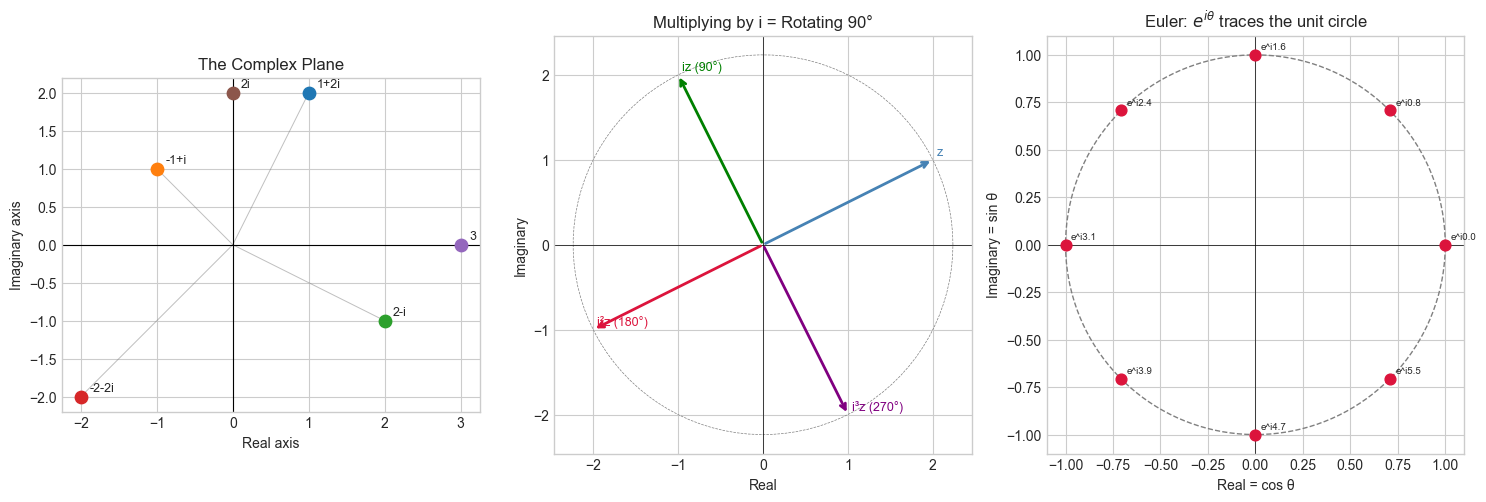

In [1]:
# --- Visualization: The complex plane and multiplication as rotation ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Complex plane with several points
ax = axes[0]
points = [1+2j, -1+1j, 2-1j, -2-2j, 3+0j, 0+2j]
labels = ['1+2i', '-1+i', '2-i', '-2-2i', '3', '2i']
for z, lbl in zip(points, labels):
    ax.scatter(z.real, z.imag, s=80, zorder=3)
    ax.annotate(lbl, (z.real, z.imag), textcoords='offset points', xytext=(6,4), fontsize=9)
    ax.plot([0, z.real], [0, z.imag], 'gray', linewidth=0.7, alpha=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Real axis')
ax.set_ylabel('Imaginary axis')
ax.set_title('The Complex Plane')
ax.set_aspect('equal')

# Plot 2: Multiplication by i = rotation by 90°
ax = axes[1]
z0 = 2 + 1j
colors = ['steelblue', 'green', 'crimson', 'purple']
zs = [z0 * (1j**k) for k in range(4)]
labels2 = ['z', 'iz (90°)', 'i²z (180°)', 'i³z (270°)']
for z, c, lbl in zip(zs, colors, labels2):
    ax.annotate('', xy=(z.real, z.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2))
    ax.annotate(lbl, (z.real, z.imag), color=c, fontsize=9, xytext=(3, 3),
                textcoords='offset points')
theta = np.linspace(0, 2*np.pi, 100)
r = abs(z0)
ax.plot(r*np.cos(theta), r*np.sin(theta), 'gray', linewidth=0.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
ax.set_title('Multiplying by i = Rotating 90°')

# Plot 3: Euler's formula on the unit circle
ax = axes[2]
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'gray', linewidth=1, linestyle='--', label='Unit circle')
sample_angles = np.linspace(0, 2*np.pi, 9)[:-1]
for t in sample_angles:
    z = np.exp(1j * t)
    ax.scatter(z.real, z.imag, color='crimson', s=60, zorder=3)
    ax.annotate(f'e^i{t:.1f}', (z.real, z.imag), fontsize=7, xytext=(4, 4),
                textcoords='offset points')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.set_xlabel('Real = cos θ')
ax.set_ylabel('Imaginary = sin θ')
ax.set_title("Euler: $e^{i\\theta}$ traces the unit circle")

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Complex number:** $z = a + bi$, $a, b \in \mathbb{R}$, $i^2 = -1$

**Operations:**
- Addition: $(a+bi) + (c+di) = (a+c) + (b+d)i$
- Multiplication: $(a+bi)(c+di) = (ac-bd) + (ad+bc)i$
- Conjugate: $\bar{z} = a - bi$
- Modulus: $|z| = \sqrt{a^2+b^2} = \sqrt{z\bar{z}}$
- Polar form: $z = r e^{i\theta} = r(\cos\theta + i\sin\theta)$, where $r = |z|$, $\theta = \arg(z)$

**Euler's formula:** $e^{i\theta} = \cos\theta + i\sin\theta$ (follows from Taylor series of $e^x$, $\cos x$, $\sin x$)

**De Moivre's theorem:** $(\cos\theta + i\sin\theta)^n = \cos(n\theta) + i\sin(n\theta)$

**Fundamental theorem of algebra:** Every non-constant polynomial $p(z)$ with complex coefficients has a complex root.

## 5. Python Implementation

In [2]:
# --- Implementation: Complex arithmetic and polar form ---
import numpy as np
import cmath

def complex_info(z):
    """
    Display all key properties of a complex number.

    Args:
        z: complex
    """
    print(f"  z             = {z}")
    print(f"  Re(z)         = {z.real}")
    print(f"  Im(z)         = {z.imag}")
    print(f"  conj(z)       = {z.conjugate()}")
    print(f"  |z|           = {abs(z):.6f}")
    print(f"  arg(z)        = {cmath.phase(z):.6f} rad = {np.degrees(cmath.phase(z)):.2f}°")
    r, theta = cmath.polar(z)
    print(f"  polar (r,θ)   = ({r:.4f}, {theta:.4f})")
    z_reconstructed = cmath.rect(r, theta)
    print(f"  Reconstructed = {z_reconstructed:.6f}")


def complex_multiply_polar(z1, z2):
    """
    Multiply two complex numbers using polar form.
    Result: magnitude = |z1|*|z2|, angle = arg(z1)+arg(z2)

    Args:
        z1, z2: complex

    Returns:
        complex
    """
    r1, t1 = cmath.polar(z1)
    r2, t2 = cmath.polar(z2)
    return cmath.rect(r1 * r2, t1 + t2)


# Verify Euler's formula
print("Euler's formula: e^(iπ) + 1 = 0")
val = np.exp(1j * np.pi) + 1
print(f"  e^(iπ) + 1 = {val}  (should be ~0)")

print("\nComplex number info:")
complex_info(3 + 4j)

print("\nPolar multiplication:")
z1, z2 = 1+1j, 0+1j  # 1+i times i
direct = z1 * z2
polar = complex_multiply_polar(z1, z2)
print(f"  (1+i) × i = {direct}  (polar: {polar:.4f})")

# nth roots of unity
print("\n5th roots of unity (z^5 = 1):")
for k in range(5):
    root = np.exp(2j * np.pi * k / 5)
    verify = root**5
    print(f"  k={k}: {root:.4f}  →  z^5 = {verify:.4f}")

Euler's formula: e^(iπ) + 1 = 0
  e^(iπ) + 1 = 1.2246467991473532e-16j  (should be ~0)

Complex number info:
  z             = (3+4j)
  Re(z)         = 3.0
  Im(z)         = 4.0
  conj(z)       = (3-4j)
  |z|           = 5.000000
  arg(z)        = 0.927295 rad = 53.13°
  polar (r,θ)   = (5.0000, 0.9273)
  Reconstructed = 3.000000+4.000000j

Polar multiplication:
  (1+i) × i = (-1+1j)  (polar: -1.0000+1.0000j)

5th roots of unity (z^5 = 1):
  k=0: 1.0000+0.0000j  →  z^5 = 1.0000+0.0000j
  k=1: 0.3090+0.9511j  →  z^5 = 1.0000-0.0000j
  k=2: -0.8090+0.5878j  →  z^5 = 1.0000-0.0000j
  k=3: -0.8090-0.5878j  →  z^5 = 1.0000-0.0000j
  k=4: 0.3090-0.9511j  →  z^5 = 1.0000-0.0000j


## 6. Experiments

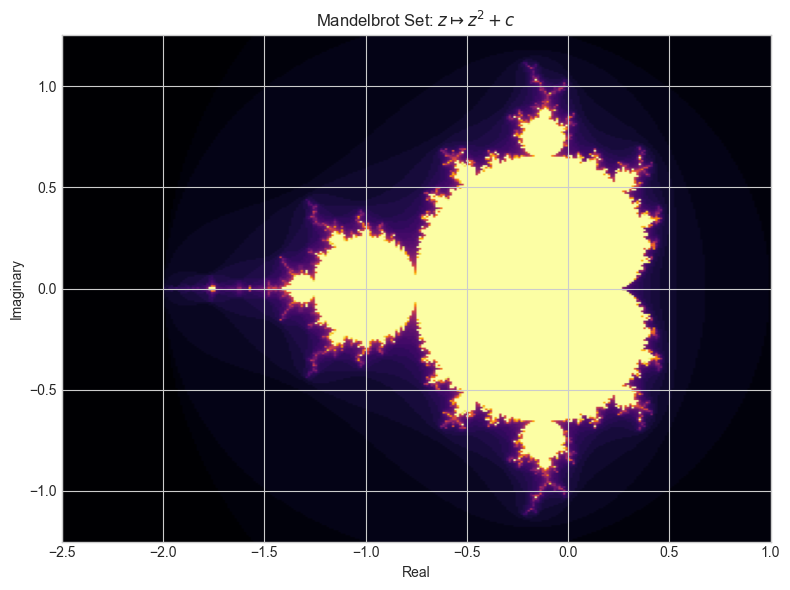

In [3]:
# --- Experiment 1: The Mandelbrot set via iterated complex maps ---
# Hypothesis: the boundary of the set z -> z^2 + c is fractal
# Try changing: RESOLUTION, MAX_ITER
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

RESOLUTION = 300  # <-- modify this
MAX_ITER = 50     # <-- modify this

x = np.linspace(-2.5, 1.0, RESOLUTION)
y = np.linspace(-1.25, 1.25, RESOLUTION)
C = x[np.newaxis, :] + 1j * y[:, np.newaxis]

Z = np.zeros_like(C)
escape = np.zeros(C.shape, dtype=int)

for i in range(MAX_ITER):
    mask = np.abs(Z) <= 2
    Z[mask] = Z[mask]**2 + C[mask]
    escape += mask.astype(int)

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(escape, extent=[-2.5, 1, -1.25, 1.25], cmap='inferno', origin='lower')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
ax.set_title('Mandelbrot Set: $z \\mapsto z^2 + c$')
plt.tight_layout()
plt.show()

## 7. Exercises

**Easy 1.** Compute $(3+4i)^2$ by hand (expand $(a+bi)^2 = a^2-b^2 + 2abi$) and verify in Python.

**Easy 2.** Find all fourth roots of 16 (i.e., solve $z^4 = 16$) using `z = np.exp(2j*np.pi*k/4) * 16**(1/4)` for $k=0,1,2,3$. Verify each root satisfies $z^4 = 16$.

**Medium 1.** Implement a 2D rotation function `rotate(points, angle_deg)` that rotates an array of 2D points using complex multiplication: represent $(x, y)$ as $x + iy$, multiply by $e^{i\theta}$, extract the result.

**Medium 2.** Prove De Moivre's theorem computationally: verify $(\cos\theta + i\sin\theta)^n = \cos(n\theta) + i\sin(n\theta)$ for $n=1,\ldots,20$ and $\theta = 1.23$ rad.

**Hard.** The Discrete Fourier Transform decomposes a signal into complex exponentials $e^{2\pi i k n / N}$. Implement the DFT from scratch using only complex arithmetic (no `np.fft`). Apply it to a sum of two sine waves and verify you can recover both frequencies from the magnitude spectrum.

## 8. Mini Project

In [ ]:
# --- Mini Project: 2D Rotation Engine via Complex Multiplication ---
# Problem: Computer graphics rotation is done via matrix multiplication,
#          but complex multiplication is an equally valid (and sometimes faster) approach.
# Task: Implement a polygon transformer using complex arithmetic.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def make_polygon(n_sides, radius=1.0, center=(0,0)):
    """Generate vertices of regular n-gon as complex numbers."""
    angles = np.linspace(0, 2*np.pi, n_sides, endpoint=False)
    return radius * np.exp(1j * angles) + complex(*center)

def rotate_complex(points, angle_rad, pivot=0+0j):
    """
    Rotate complex points around a pivot using multiplication by e^(i*angle).

    Args:
        points: array of complex
        angle_rad: float, rotation angle
        pivot: complex, center of rotation

    Returns:
        array of complex: rotated points
    """
    # TODO: implement: translate to origin, rotate, translate back
    pass

def scale_complex(points, factor, center=0+0j):
    """Scale points from a center."""
    # TODO: implement
    pass

# Animate a rotating pentagon
fig, ax = plt.subplots(figsize=(6, 6))
pentagon = make_polygon(5, radius=1.0)

def plot_poly(ax, pts, color, label=''):
    closed = np.append(pts, pts[0])
    ax.plot(closed.real, closed.imag, '-o', color=color, linewidth=2, label=label)

angles = np.linspace(0, np.pi, 5)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(angles)))
for angle, color in zip(angles, colors):
    rotated = rotate_complex(pentagon, angle)
    if rotated is not None:
        plot_poly(ax, rotated, color, label=f'{np.degrees(angle):.0f}°')

ax.set_aspect('equal')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Pentagon Rotations via Complex Multiplication')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- Complex numbers complete the number tower: ℂ closes ℝ under taking square roots of negatives.
- Geometric interpretation: complex numbers are 2D vectors; multiplication encodes rotation and scaling.
- Euler's formula $e^{i\theta} = \cos\theta + i\sin\theta$ unifies exponentials and trigonometry.
- The Fundamental Theorem of Algebra holds only over ℂ — every polynomial of degree $n$ has exactly $n$ roots.

**Forward connections:**
- Complex multiplication as rotation is the precursor to ch118–119 (Geometric Transformations) and ch165 (Rotation via Matrices).
- The DFT exercise previews ch027's role in signal processing — the FFT appears as an application in Part IX.
- The Mandelbrot set appears again as an example of iteration and chaos in ch084 (Chaos and Sensitivity).

**Backward connection:**
- This chapter closes the number tower started in ch021. Every number system is now defined and its closure properties understood.

**Going deeper:** Quaternions extend complex numbers to four dimensions and are used in 3D graphics engines for rotation without gimbal lock. Look up "quaternion rotation" when working in 3D geometry.